# Auto gap validation — Huang+2018 half-depth, algorithmic


In [19]:
import sys, pickle, os
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

sys.path.insert(0, r'D:\CPD_MPIA\Median_SNR')

DATA_DIR = r'D:\exoALMA_disk_data'
PKL_FILE = r'D:\CPD_MPIA\Median_SNR\disk_object_files\all_disks.pkl'
LOG_FILE = r'D:\CPD_MPIA\Injection_Recovery_Revised\gap_clicks.csv'
OUT_CSV  = r'D:\CPD_MPIA\Injection_Recovery_Revised\gap_auto.csv'

with open(PKL_FILE, 'rb') as f:
    all_disks = pickle.load(f)

def get_beam_fwhm_as(disk):
    """Geometric-mean FWHM [arcsec] at robust=-0.5."""
    bi   = all_disks[disk].beam_info.get('-0.5', {})
    bmaj = bi.get('beam_x_arcsec', None)
    bmin = bi.get('beam_y_arcsec', None)
    if bmaj and bmin:
        return float(np.sqrt(bmaj * bmin))
    return float(getattr(all_disks[disk], 'beam_arcsec', 0.065))

def load_profile(disk):
    """Returns r_as, r_au, I_mJy, dI_mJy."""
    path = os.path.join(DATA_DIR, disk, f'{disk}_CLEAN_profile_robust-05.txt')
    d = np.loadtxt(path, comments='#')
    return d[:, 0], d[:, 1], d[:, 2], d[:, 3]

print('Ready.')

Ready.


In [20]:
def find_auto_gap(r_au, I, r_seed_au, r_ring_seed_au, beam_fwhm_au,
                  method='huang2018', fwhm_mult=0.5,
                  smooth_sigma_fwhm=0.5, search_window_fwhm=2.0):
    """
    Algorithmically refine a gap measurement seeded from a manual click.

    Parameters
    ----------
    r_au, I          : radial profile arrays (AU, mJy/beam)
    r_seed_au        : manual gap_dip location [AU] — seed for local-min search
    r_ring_seed_au   : outer ring peak location [AU] — ring is always outside the gap
    beam_fwhm_au     : beam FWHM [AU]
    method           : 'huang2018' or 'cavity_Nfwhm'
    fwhm_mult        : N for cavity inner-edge (e.g. 0.5, 1.0)
    smooth_sigma_fwhm: Gaussian smoothing σ as fraction of beam FWHM
    search_window_fwhm: half-width of dip search window in FWHMs

    Returns
    -------
    dict: r_dip, r_ring, r_inner, r_outer, w_gap, I_dip, I_ring, I_mean
    """
    dr = r_au[1] - r_au[0]

    # Gaussian-smoothed profile for robust extremum finding
    sigma_idx = smooth_sigma_fwhm * beam_fwhm_au / dr
    I_sm = gaussian_filter1d(I, sigma=max(sigma_idx, 1.0))

    # ── 1. Find gap dip — local minimum near seed ─────────────────────
    win_au = search_window_fwhm * beam_fwhm_au
    lo = max(r_au[0],  r_seed_au - win_au)
    hi = min(r_au[-1], r_seed_au + win_au)
    # Don't let search window reach the outer ring
    hi = min(hi, r_ring_seed_au)

    msk = (r_au >= lo) & (r_au <= hi)
    if msk.sum() >= 3:
        idx_dip = np.argmin(I_sm[msk])
        r_dip   = float(r_au[msk][idx_dip])
        I_dip   = float(I[msk][idx_dip])
    else:
        r_dip = r_seed_au
        I_dip = float(np.interp(r_seed_au, r_au, I))

    # ── 2. Find ring peak — local maximum on smoothed profile (outward) ─
    span    = abs(r_ring_seed_au - r_seed_au)
    ring_hi = min(r_au[-1], r_ring_seed_au + span)
    msk_r   = (r_au > r_dip) & (r_au <= ring_hi)

    if msk_r.sum() >= 3:
        idx_ring = np.argmax(I_sm[msk_r])
        r_ring   = float(r_au[msk_r][idx_ring])
        I_ring   = float(I[msk_r][idx_ring])
    else:
        r_ring = r_ring_seed_au
        I_ring = float(np.interp(r_ring_seed_au, r_au, I))
    I_mean = 0.5 * (I_dip + I_ring)

    # ── 3. Edge crossing helpers ──────────────────────
    def first_cross_up(rv, Iv, fallback):
        """First upward crossing of I_mean (left→right)."""
        for k in range(len(rv) - 1):
            if Iv[k] <= I_mean <= Iv[k + 1]:
                f = (I_mean - Iv[k]) / (Iv[k+1] - Iv[k] + 1e-30)
                return float(rv[k] + f * (rv[k+1] - rv[k]))
        return fallback

    def last_cross_dn(rv, Iv, fallback):
        """Last downward crossing of I_mean going left from r_dip."""
        for k in range(len(rv) - 1, 0, -1):
            if Iv[k] <= I_mean <= Iv[k - 1]:
                f = (I_mean - Iv[k]) / (Iv[k-1] - Iv[k] + 1e-30)
                return float(rv[k] + f * (rv[k-1] - rv[k]))
        return fallback

    # ── 4. Place inner / outer edges ──────────────────
    is_cavity = method.startswith('cavity')

    if is_cavity:
        # Inner edge: beam-based (same rule as manual tool)
        r_inner = max(r_au[0], r_dip - fwhm_mult * beam_fwhm_au)
        # Outer edge: I_mean crossing toward outer ring
        msk_out = (r_au >= r_dip) & (r_au <= max(r_ring, r_dip + dr))
        r_outer = first_cross_up(r_au[msk_out], I[msk_out],
                                  float(r_au[msk_out][-1]))
    else:
        # Standard Huang: outer ring
        msk_out = (r_au >= r_dip) & (r_au <= r_ring)
        r_outer = first_cross_up(r_au[msk_out], I[msk_out],
                                  float(r_au[msk_out][-1]))
        msk_in  = r_au <= r_dip
        r_inner = last_cross_dn(r_au[msk_in], I[msk_in],
                                 float(r_au[msk_in][0]))

    return dict(
        r_dip   = round(float(r_dip),   2),
        r_ring  = round(float(r_ring),  2),
        r_inner = round(float(r_inner), 2),
        r_outer = round(float(r_outer), 2),
        w_gap   = round(float(r_outer - r_inner), 2),
        I_dip   = round(I_dip,  5),
        I_ring  = round(I_ring, 5),
        I_mean  = round(I_mean, 5),
    )

print('Algorithm defined.')

Algorithm defined.


In [21]:
# ── Load manual CSV and run auto algorithm on every gap set ──────────────
df_man = pd.read_csv(LOG_FILE)

# Each gap set = 4 consecutive rows
n_sets = len(df_man) // 4
print(f'{n_sets} gap sets in {LOG_FILE}')

results = []
for i in range(n_sets):
    block   = df_man.iloc[i*4 : i*4 + 4].reset_index(drop=True)
    row_dip  = block[block['label'] == 'gap_dip'  ].iloc[0]
    row_ring = block[block['label'] == 'ring_peak' ].iloc[0]
    row_in   = block[block['label'] == 'inner_edge'].iloc[0]
    row_out  = block[block['label'] == 'outer_edge'].iloc[0]

    disk   = row_dip['disk']
    method = row_dip['method']

    try:
        _, r_au, I, dI = load_profile(disk)
    except Exception as e:
        print(f'  {disk}: SKIP — profile load failed: {e}')
        continue

    dist         = all_disks[disk].distance_pc
    beam_fwhm_as = get_beam_fwhm_as(disk)
    beam_fwhm_au = beam_fwhm_as * dist

    # Parse fwhm_mult from method string e.g. 'cavity_0.5fwhm' → 0.5
    fwhm_mult = 0.5
    if method.startswith('cavity'):
        try:
            fwhm_mult = float(method.split('_')[1].replace('fwhm', ''))
        except Exception:
            fwhm_mult = 0.5

    res = find_auto_gap(
        r_au, I,
        r_seed_au      = row_dip['r_au'],
        r_ring_seed_au = row_ring['r_au'],
        beam_fwhm_au   = beam_fwhm_au,
        method         = method,
        fwhm_mult      = fwhm_mult,
    )

    man_w = row_out['r_au'] - row_in['r_au']
    results.append(dict(
        disk          = disk,
        method        = method,
        beam_fwhm_au  = round(beam_fwhm_au, 2),
        # manual
        man_r_dip   = row_dip['r_au'],
        man_r_ring  = row_ring['r_au'],
        man_r_inner = row_in['r_au'],
        man_r_outer = row_out['r_au'],
        man_w_gap   = round(man_w, 2),
        # auto
        auto_r_dip   = res['r_dip'],
        auto_r_ring  = res['r_ring'],
        auto_r_inner = res['r_inner'],
        auto_r_outer = res['r_outer'],
        auto_w_gap   = res['w_gap'],
        auto_I_mean  = res['I_mean'],
        # differences (auto − manual)
        d_r_dip   = round(res['r_dip']   - row_dip['r_au'], 2),
        d_r_inner = round(res['r_inner'] - row_in['r_au'],  2),
        d_r_outer = round(res['r_outer'] - row_out['r_au'], 2),
        d_w_gap   = round(res['w_gap']   - man_w,           2),
    ))

    print(f'  {disk:12s}  [{method:18s}]  '
          f'dip {row_dip["r_au"]:5.1f}→{res["r_dip"]:5.1f} AU  '
          f'w {man_w:5.1f}→{res["w_gap"]:5.1f} AU  '
          f'  Δdip={res["r_dip"]-row_dip["r_au"]:+.1f}  Δw={res["w_gap"]-man_w:+.1f}')

df_res = pd.DataFrame(results)
df_res.to_csv(OUT_CSV, index=False)
print(f'\nSaved → {OUT_CSV}')

13 gap sets in D:\CPD_MPIA\Injection_Recovery_Revised\gap_clicks.csv
  AA_Tau        [huang2018         ]  dip  15.5→ 17.5 AU  w  23.7→ 23.6 AU    Δdip=+2.0  Δw=-0.0
  AA_Tau        [huang2018         ]  dip  70.5→ 76.8 AU  w  19.8→ 15.6 AU    Δdip=+6.3  Δw=-4.2
  CQ_Tau        [cavity_0.5fwhm    ]  dip   6.4→  1.5 AU  w  23.5→ 23.6 AU    Δdip=-4.9  Δw=+0.1
  DM_Tau        [cavity_0.5fwhm    ]  dip  11.0→ 10.1 AU  w  12.2→ 13.1 AU    Δdip=-1.0  Δw=+0.8
  DM_Tau        [cavity_0.5fwhm    ]  dip  70.8→ 73.4 AU  w  15.5→ 12.6 AU    Δdip=+2.6  Δw=-2.9
  J1615         [cavity_0.5fwhm    ]  dip   7.8→  1.6 AU  w  15.6→ 15.6 AU    Δdip=-6.2  Δw=-0.1
  J1842         [cavity_0.5fwhm    ]  dip   3.9→  1.5 AU  w  23.4→ 23.4 AU    Δdip=-2.4  Δw=+0.0
  J1852         [cavity_0.5fwhm    ]  dip  26.9→  4.4 AU  w  21.1→ 40.3 AU    Δdip=-22.5  Δw=+19.1
  LkCa_15       [cavity_0.5fwhm    ]  dip  11.3→  7.9 AU  w  47.4→ 50.8 AU    Δdip=-3.4  Δw=+3.3
  LkCa_15       [huang2018         ]  dip  87.9→ 95.9 AU

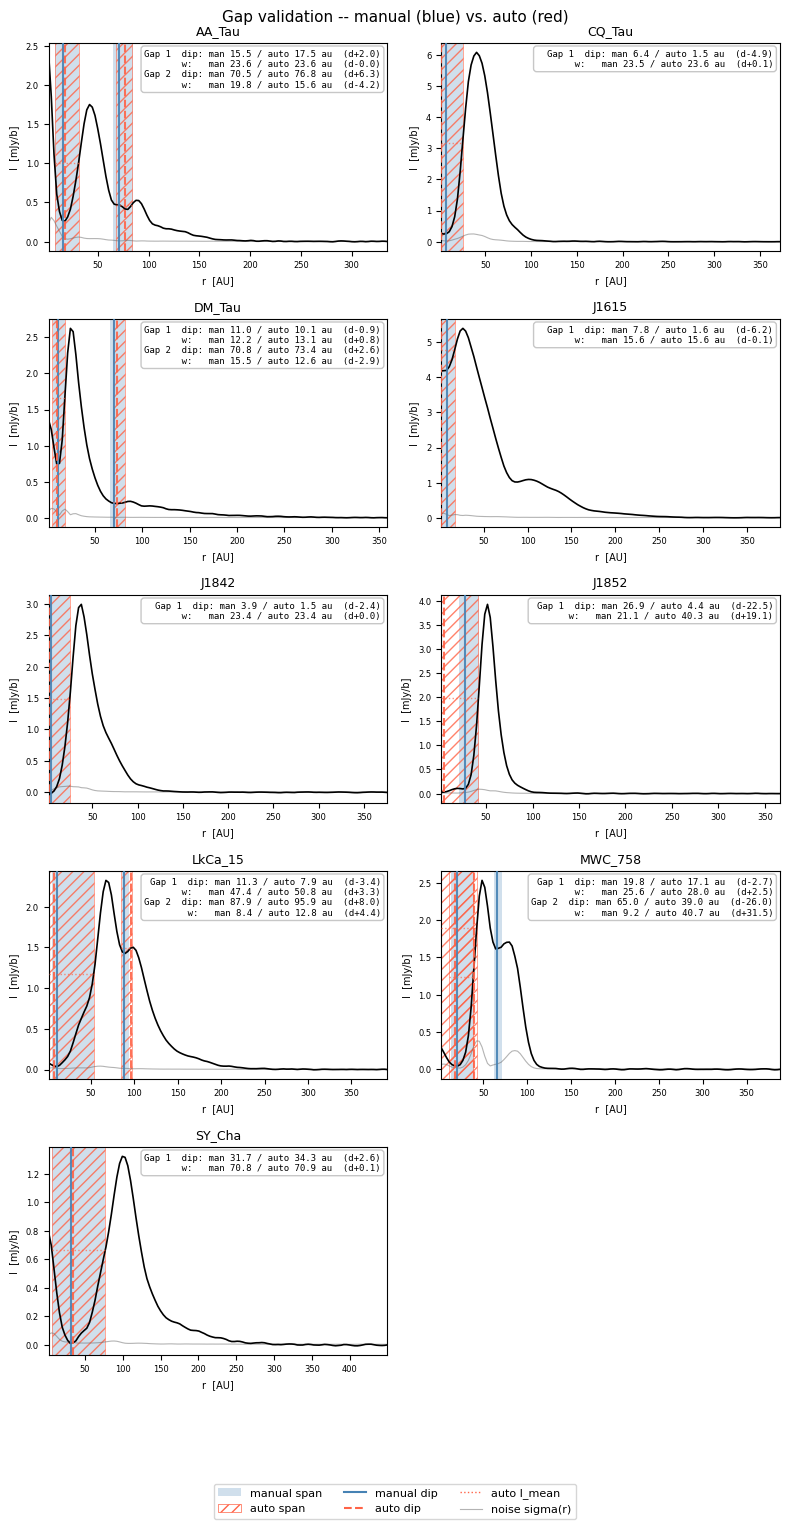

Saved: D:\CPD_MPIA\Injection_Recovery_Revised\gap_auto_validation.png


In [23]:
# -- Overlaid plot: blue=manual, red=auto ------------------------------------
import matplotlib.pyplot as plt

clicked_disks = sorted(df_res['disk'].unique())
ncols = 2
nrows = int(np.ceil(len(clicked_disks) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.0 * nrows))
axes = np.array(axes).flatten()

C_MAN  = 'steelblue'
C_AUTO = 'tomato'

for i, disk in enumerate(clicked_disks):
    ax = axes[i]
    try:
        _, r_au, I, dI = load_profile(disk)
    except Exception as e:
        ax.text(0.5, 0.5, 'profile missing' + chr(10) + str(e),
                ha='center', va='center',
                transform=ax.transAxes, fontsize=7, color='red')
        ax.set_title(disk, fontsize=8)
        continue

    ax.plot(r_au, I,  color='k',       lw=1.2, zorder=3)
    ax.plot(r_au, dI, color='dimgray', lw=0.8, ls='-', alpha=0.5, zorder=2)

    sub = df_res[df_res['disk'] == disk].reset_index(drop=True)
    for _, row in sub.iterrows():

        # manual: solid blue fill + solid blue vline
        ax.axvspan(row['man_r_inner'], row['man_r_outer'],
                   facecolor=C_MAN, alpha=0.25, linewidth=0, zorder=1)
        ax.axvline(row['man_r_dip'],
                   color=C_MAN, lw=1.5, ls='-', alpha=0.9, zorder=4)

        # auto: red hatch + red dashed vline
        ax.axvspan(row['auto_r_inner'], row['auto_r_outer'],
                   facecolor='none', edgecolor=C_AUTO, hatch='///',
                   linewidth=0.5, alpha=0.8, zorder=1)
        ax.axvline(row['auto_r_dip'],
                   color=C_AUTO, lw=1.5, ls='--', alpha=0.9, zorder=4)

        # auto I_mean threshold level
        ax.hlines(row['auto_I_mean'],
                  row['auto_r_inner'], row['auto_r_outer'],
                  colors=C_AUTO, lw=1.0, ls=':', alpha=0.7, zorder=5)

    # Text box: manual vs auto r_dip and w for each gap
    lines = []
    for gi, (_, row) in enumerate(sub.iterrows()):
        lines.append(
            f'Gap {gi+1}  dip: man {row["man_r_dip"]:.1f} / auto {row["auto_r_dip"]:.1f} au'
            f'  (d{row["d_r_dip"]:+.1f})'
        )
        lines.append(
            f'       w:   man {row["man_w_gap"]:.1f} / auto {row["auto_w_gap"]:.1f} au'
            f'  (d{row["d_w_gap"]:+.1f})'
        )
    if lines:
        ax.text(0.98, 0.97, chr(10).join(lines),
                transform=ax.transAxes, ha='right', va='top',
                fontsize=6.5, family='monospace',
                bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                          edgecolor='silver', alpha=0.88))

    ax.set_title(disk, fontsize=9)
    ax.set_xlabel('r  [AU]', fontsize=7)
    ax.set_ylabel('I  [mJy/b]', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_xlim(r_au.min(), r_au.max())

for j in range(len(clicked_disks), len(axes)):
    axes[j].set_visible(False)

legend_els = [
    mpatches.Patch(facecolor=C_MAN,  alpha=0.25, linewidth=0, label='manual span'),
    mpatches.Patch(facecolor='none', edgecolor=C_AUTO, hatch='///',
                   linewidth=0.5, label='auto span'),
    Line2D([0],[0], color=C_MAN,  lw=1.5, ls='-',  label='manual dip'),
    Line2D([0],[0], color=C_AUTO, lw=1.5, ls='--', label='auto dip'),
    Line2D([0],[0], color=C_AUTO, lw=1.0, ls=':',  label='auto I_mean'),
    Line2D([0],[0], color='dimgray', lw=0.8, ls='-', alpha=0.5, label='noise sigma(r)'),
]
fig.legend(handles=legend_els, loc='lower center', ncol=3, fontsize=8,
           bbox_to_anchor=(0.5, -0.03))

plt.suptitle('Gap validation -- manual (blue) vs. auto (red)', fontsize=11)
plt.tight_layout(rect=[0, 0.05, 1, 1])

out_png = r'D:\CPD_MPIA\Injection_Recovery_Revised\gap_auto_validation.png'
plt.savefig(out_png, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {out_png}')


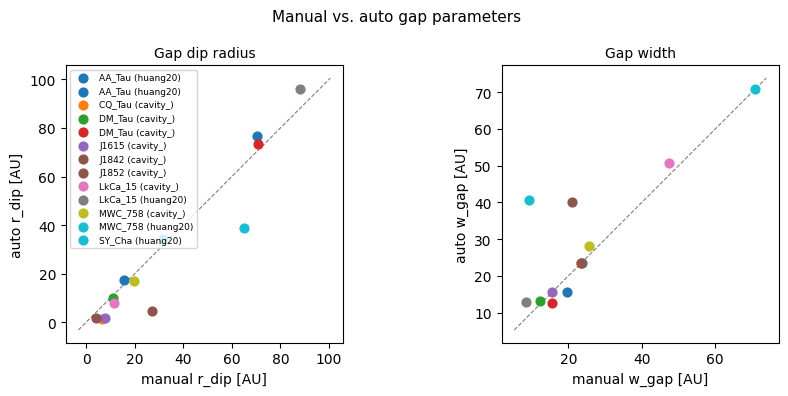

Saved: D:\CPD_MPIA\Injection_Recovery_Revised\gap_auto_scatter.png


In [24]:
# ── Scatter: manual vs auto (r_dip and w_gap) ─────────────────────────────
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

colors = plt.cm.tab10(np.linspace(0, 1, len(df_res)))

for ci, (_, row) in zip(colors, df_res.iterrows()):
    label = f"{row['disk']} ({row['method'][:7]})"
    ax1.scatter(row['man_r_dip'],  row['auto_r_dip'],  color=ci, s=40, label=label)
    ax2.scatter(row['man_w_gap'],  row['auto_w_gap'],  color=ci, s=40)

for ax, title, xlabel, ylabel in [
    (ax1, 'Gap dip radius',  'manual r_dip [AU]', 'auto r_dip [AU]'),
    (ax2, 'Gap width',       'manual w_gap [AU]', 'auto w_gap [AU]'),
]:
    vmin = min(ax.get_xlim()[0], ax.get_ylim()[0])
    vmax = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([vmin, vmax], [vmin, vmax], 'k--', lw=0.8, alpha=0.5, zorder=0)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.set_aspect('equal')

ax1.legend(fontsize=6.5, loc='upper left', ncol=1)
plt.suptitle('Manual vs. auto gap parameters', fontsize=11)
plt.tight_layout()
out_sc = r'D:\CPD_MPIA\Injection_Recovery_Revised\gap_auto_scatter.png'
plt.savefig(out_sc, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {out_sc}')